# Exercise set 3
(Aggarwal 2.7)

Download the Musk data set from the UCI Machine Learning Repository. Apply PCA to the data set, and report the eigenvectors and eigenvalues (hint: pca implemented in sklearn)

In [1]:
import pandas as pd
import numpy as np

#========================
# Caricamento e pulizia

#creo le etichette per il dataset

nomi_testo = ['molecules', 'conformation']

nomi_numerici = list(range(166))

nome_classe=['classe']

labels = nomi_testo + nomi_numerici + nome_classe

#utilizzo le etichette che ho creato come nomi per le features
df = pd.read_csv('_musk/clean2.data', names=labels)

# pulizia dei dati

df.replace('?', 0, inplace=True)

# La PCA lavora solo con i numeri, quindi dobbiamo togliere le stringhe iniziali e la classe finale.

df2=df.iloc[:, 2:-1]

# Convertiamo in una matrice NumPy che ci serve per usare sklearn

d = df2.to_numpy(copy=True)
#========================


#========================
# PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=0.8, svd_solver='full')
"""
    Il parametro chiave qui è n_components=0.8.
    Se metti un numero intero (es. 2), gli dici: "Dammi 2 colonne".
    Se metti un decimale (es. 0.8), gli dici: "Tienimi tutte le colonne necessarie per spiegare l'80% dell'informazione (varianza)".
"""

d_new = pca.fit(d).transform(d)
"""
Qui stiamo concatenando due azioni in una riga sola.

.fit(d) (La fase di Apprendimento):
    Il modello "guarda" i tuoi dati d.
    Calcola la media di ogni colonna.
    Calcola la matrice di covarianza.
    Trova le direzioni principali (gli assi) dove i dati variano di più.
    In breve: Impara la struttura dei dati.
    
.transform(d) (La fase di Azione):
    Prende i dati originali d.
    Li proietta (li sposta) sul nuovo sistema di coordinate che ha appena imparato.
    Taglia via le colonne inutili (quelle che spiegano poco, il "rumore").
    In breve: Crea la versione compressa dei dati.
"""

# --- VERIFICHE ---
print(f"Numero di componenti mantenute: {pca.n_components_}")
print(f"Nuova forma dei dati: {d_new.shape}")

# Questi sono i valori che chiedeva l'esercizio (Valori Singolari)
print("Valori singolari (primi 5):")
print(pca.singular_values_[:5])

Numero di componenti mantenute: 11
Nuova forma dei dati: (6598, 11)
Valori singolari (primi 5):
[54850.42103375 41247.0446625  22372.88299965 17424.14411487
 16335.2392005 ]


(Aggarwal 2.8)

Repeat the previous exercise using SVD (hint: svd implemented in numpy.linalg.svd)

Confronto dei primi 5 Valori Singolari:
SVD (NumPy - Dati Grezzi): [87765.40969139 54418.11086264 36875.51290651 22121.42906393
 17210.02170661]
PCA (Sklearn - Automatico: [54850.42103375 41247.0446625  22372.88299965 17424.14411487
 16335.2392005 ])


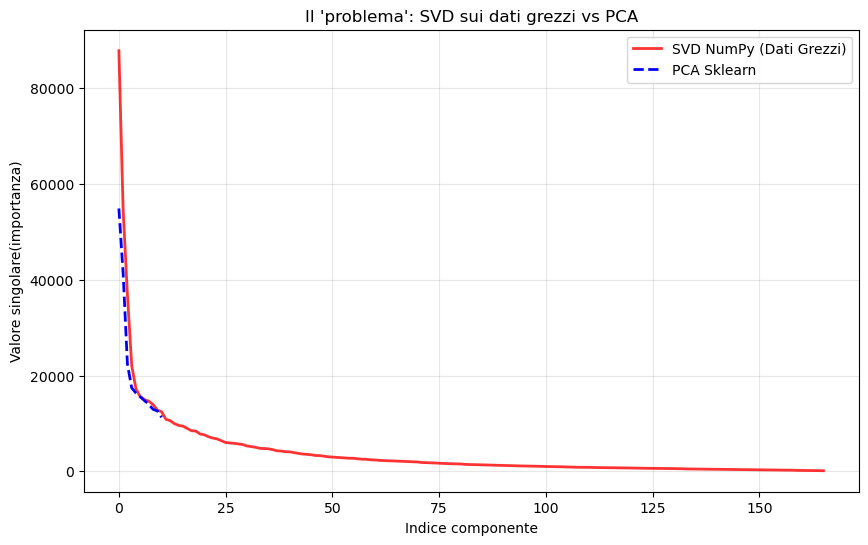

In [3]:
#========================
# SVD
from numpy.linalg import svd
import matplotlib.pyplot as plt

#-- 1. Calcolo SVD sui dati grezzi --
# compute_uv=false restituisce il vettore SIGMA  (dei valori singolari)
# Risparmiamo memoria perche' ora non ci servono le matrici U e V
sigma = svd(d, compute_uv=False)

#-- 2. Confronto numerico --
print("Confronto dei primi 5 Valori Singolari:")
print(f"SVD (NumPy - Dati Grezzi): {sigma[:5]}")
print(f"PCA (Sklearn - Automatico: {pca.singular_values_[:5]})")

#-- 3. Confronto grafico --
plt.figure(figsize=(10,6))

#Disegniamo la curva della SVD in Rosso 
plt.plot(sigma, color='red', label='SVD NumPy (Dati Grezzi)', linewidth=2, alpha=0.8)

#Disegniamo la curva della PCA in blu tratteggiata
plt.plot(pca.singular_values_, color='blue', label='PCA Sklearn', linestyle='--', linewidth='2')

plt.title("Il 'problema': SVD sui dati grezzi vs PCA")
plt.xlabel('Indice componente')
plt.ylabel('Valore singolare(importanza)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- Confronto dopo la centratura ---
SVD Centrata (primi 5): [54850.42103375 41247.0446625  22372.88299965 17424.14411487
 16335.2392005 ]
PCA Sklearn (primi 5):  [54850.42103375 41247.0446625  22372.88299965 17424.14411487
 16335.2392005 ]


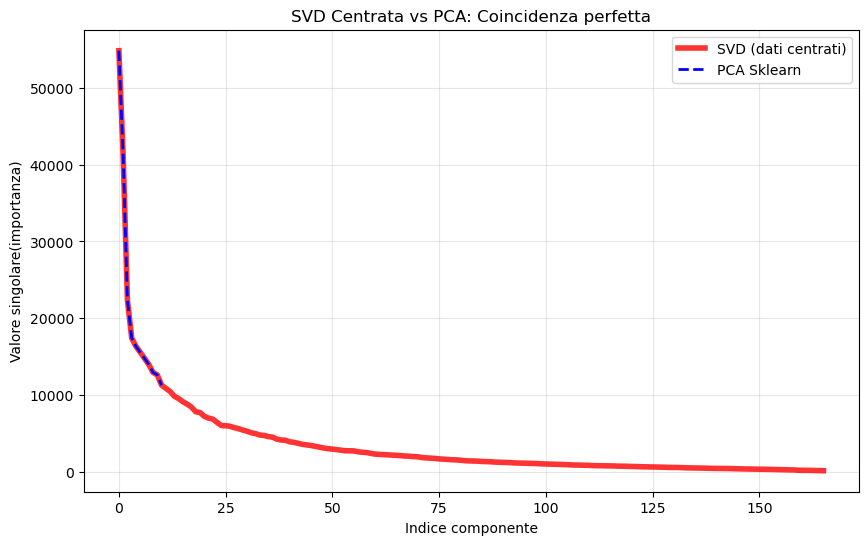


Differenza massima tra i due metodi: 0.00000


In [7]:
#--Fase 3 ---
# Centriamo i dati manualmente 

#Calcoliamo e sottraiamo manualmente la media per ogni colonna (axis=0)
media_colonne = d.mean(axis=0)

# Sottraiamo la media ai dati originali
# Questo sposta la nuvola di punti in modo che il suo centro sia (0,0,0,...)

d_centrato = d - media_colonne

# Ricalcoliamo al SVD sulla nuova matrice dei dati centrati

sigma_centrato = svd(d_centrato,compute_uv=False)

# --- VERIFICA FINALE ---
print("--- Confronto dopo la centratura ---")
print(f"SVD Centrata (primi 5): {sigma_centrato[:5]}")
print(f"PCA Sklearn (primi 5):  {pca.singular_values_[:5]}")

# -- Grafico finale --

plt.figure(figsize=(10,6))

#La linea rossa ora usera' i dati centrati
plt.plot(sigma_centrato, color='red', linewidth=4, label='SVD (dati centrati)', alpha=0.8)

# la linea blu rappresenta sempre la PCA 
plt.plot(pca.singular_values_, color='blue', linestyle="--", label='PCA Sklearn', linewidth=2)

plt.title("SVD Centrata vs PCA: Coincidenza perfetta")
plt.legend()
plt.xlabel('Indice componente')
plt.ylabel('Valore singolare(importanza)')
plt.grid(True, alpha=0.3)
plt.show()

# Calcoliamo la differenza matematica (dovrebbe essere quasi zero ovunque)
differenza = sigma_centrato[:len(pca.singular_values_)] - pca.singular_values_
print(f"\nDifferenza massima tra i due metodi: {max(abs(differenza)):.5f}")


**Cosa rappresenta la "coda" rossa?**

Quella parte della linea rossa che prosegue da sola (dall'indice 11 fino alla fine) rappresenta quel 20% di informazione che abbiamo deciso di scartare.

Parte Sovrapposta: Il segnale utile (80%).

Parte Rossa Solitaria: Il rumore o i dettagli trascurabili (20%).

Dimensione matrice covarianza: (166, 166)


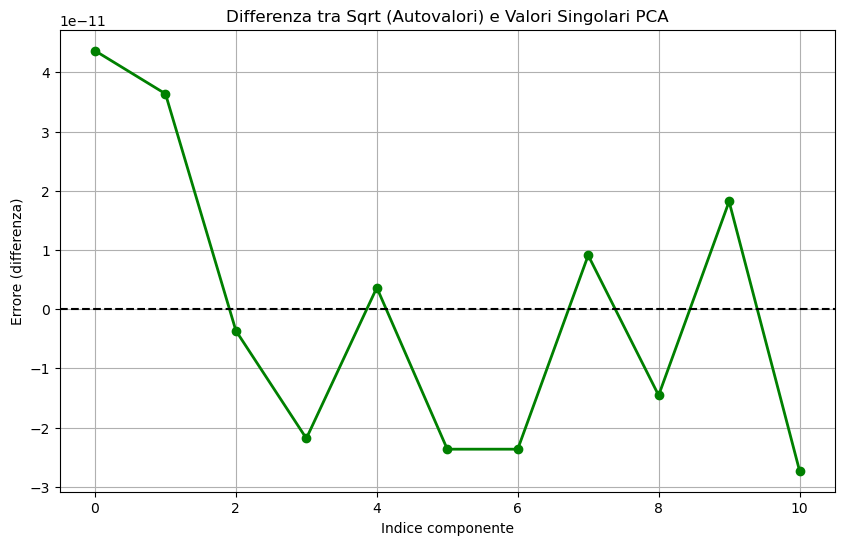

Differenza media:  2.0504971458153292e-11


In [9]:
# FASE 4: PCA tramite autovalori della matrice di Covarianza

from numpy.linalg import eig

# -- 1. Calcolo della matrice di Scatter (Covarianza non scalata)--
# Moltiplichiamo la matrice trasposta per se stessa D^T * D
# Usiamo i dati centrati calcolati al passo precedente

C = np.matmul(d_centrato.T, d_centrato)

print(f"Dimensione matrice covarianza: {C.shape}")
# Deve essere (166,166) -> Quadrata!

# -- 2. Calcolo autovalori (Eigenvalues) e autovettori (EigenVectors) --
# l = autovalori (lambda), v=autovettori

l, v = eig(C)

# -- 3. Il problema dell'ordine -- 
# La funzione eig non restituisce i valori ordinati, la PCA sì
# Quindi dobbiamo ordinare 'l' in ordine crescente

autovalori_ordinati = np.sort(l)[::-1] #Inverte l'array (dal piu' grande al piu' piccolo)

# --- 4. La Prova del Nove: Radice Quadrata ---
# Prendiamo la radice quadrata degli autovalori
radice_autovalori = np.sqrt(autovalori_ordinati)

# --- 5. Confronto Grafico ---
plt.figure(figsize=(10,6))

# Disegniamo la differenza tra i due metodi 
# Se la teoria e' giusta la differenza dovrebbe essere ZERO (o quasi, per errori di arrotondamento)
# Prendiamo solo i primi 11 valori per confrontarli con la PCA ridotta

differenza = radice_autovalori[:11]-pca.singular_values_

plt.plot(differenza, color = 'green', linewidth=2, marker='o')
plt.title("Differenza tra Sqrt (Autovalori) e Valori Singolari PCA")
plt.xlabel("Indice componente")
plt.ylabel("Errore (differenza)")
plt.axhline(y=0, color='black', linestyle='--') #linea dello zero
plt.grid(True)
plt.show()

print("Differenza media: ", np.mean(np.abs(differenza)))

